In [8]:
import numpy as np
from numba import njit
import matplotlib.pyplot as plt

In [9]:
from utils import load_and_format_sharks_gals

In [10]:
gals, groups = load_and_format_sharks_gals('/Users/sp624AA/Downloads/mocks/v0.4.0/waves_deep_gals.parquet')

/Users/sp624AA/Code/simulated_galaxy_halo/notebooks/utils.py:210: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  groups["is_red_bcg"] = groups["is_red_bcg"].fillna(False).astype(bool)


In [11]:
groups.columns

Index(['id_fof', 'ra_bcg', 'dec_bcg', 'zobs_bcg', 'total_ab_dust_Z_VISTA_bcg',
       'fof_halo_mass', 'log_fof_halo_mass', 'group_L', 'log_group_L',
       'n_group_fof', 'group_stellar_mass', 'log_group_stellar_mass', 'n_sat',
       'n_sat_red', 'n_sat_blue', 'is_red_bcg', 'is_blue_bcg'],
      dtype='object')

In [20]:
groups[['log_fof_halo_mass', 'zobs_bcg', 'is_red_bcg', 'is_blue_bcg', 'n_sat_red', 'n_sat_blue']][0:10]

,log_fof_halo_mass,zobs_bcg,is_red_bcg,is_blue_bcg,n_sat_red,n_sat_blue
0,12.183291,0.206812,False,True,0,0
1,13.494418,0.196715,False,True,0,6
2,12.076481,0.199236,False,True,0,1
3,13.294910,0.214232,False,True,0,11
4,13.085844,0.211898,False,True,0,5
5,13.394763,0.212195,False,True,0,13
6,13.190902,0.211661,False,True,0,8
7,12.709273,0.211012,False,True,0,5
8,12.468594,0.213060,False,True,2,0
9,12.168087,0.211505,False,True,1,1


In [85]:
#!/usr/bin/env python3
from __future__ import annotations

import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import Dict, Callable

from numba import njit
from scipy.optimize import curve_fit
from scipy.integrate import quad
from scipy.special import erf
from astropy.cosmology import FlatLambdaCDM


# ============================================================
# Cosmological utilities
# ============================================================

@njit
def Hubble(z, omega_matter):
    """Hubble parameter at redshift z, flat LCDM.  Units: km/s/Mpc h^-1."""
    omega_lambda = 1.0 - omega_matter
    return 100.0 * np.sqrt(omega_matter * (1.0 + z) ** 3 + omega_lambda)


@njit
def find_rho_crit(z, omega_matter):
    """Critical density at redshift z.  Units: M_sun / (Mpc/h)^3."""
    G = 4.300917270036279e-09   # (km/s)^2 Mpc / M_sun
    return 3.0 * Hubble(z, omega_matter) ** 2 / (8.0 * np.pi * G)


@njit
def find_Om(z, omega_matter):
    """Matter density parameter Omega_m(z)."""
    omega_lambda = 1.0 - omega_matter
    return (omega_matter * (1 + z) ** 3
            / (omega_matter * (1 + z) ** 3 + omega_lambda))


@njit
def find_halo_r(halo_mass, z_group, omega_matter, delta_crit=200.0):
    """
    Virial radius r_200 of a halo.

    Parameters
    ----------
    halo_mass    : float   log10(M / (M_sun/h))
    z_group      : float   redshift
    omega_matter : float
    delta_crit   : float   overdensity w.r.t. *critical* density (default 200)

    Returns
    -------
    float  r_200 in Mpc/h
    """
    mass = 10.0 ** halo_mass
    return (
        3.0 * mass
        / (4.0 * np.pi * delta_crit * find_rho_crit(z_group, omega_matter))
    ) ** (1.0 / 3.0)


@njit
def find_concentration_ratio(
    halo_mass, z=None, concentration_relation="DuttonMaccio14", delta_crit=200.0
):
    """
    NFW concentration parameter c = r_200 / r_s.

    Supported relations: 'Maccio08', 'DuttonMaccio14'.
    """
    if concentration_relation == "Maccio08":
        if delta_crit != 200.0:
            raise ValueError("delta_crit must be 200 for Maccio08.")
        return 10 ** (0.830 - 0.098 * (halo_mass - 12))

    elif concentration_relation == "DuttonMaccio14":
        if delta_crit != 200.0:
            raise ValueError("delta_crit must be 200 for DuttonMaccio14.")
        a = 0.520 + (0.905 - 0.520) * np.exp(-0.617 * (z ** 1.21))
        b = -0.101 + 0.026 * z
        return 10 ** (a + b * (halo_mass - 12))

    else:
        raise ValueError(
            "Invalid concentration relation. Choose 'Maccio08' or 'DuttonMaccio14'."
        )


C_KMS = 299792.458

@njit
def chi_comoving_mpc_over_h(z, omega_matter, n=2048):
    """
    Comoving radial distance chi(z) in (Mpc/h), consistent with Hubble() that
    returns 100*E(z) km/s/(Mpc/h).
    Uses simple trapezoid integration (Numba-friendly).
    """
    if z <= 0.0:
        return 0.0
    zz = np.linspace(0.0, z, n)
    # H(z) is in km/s/(Mpc/h) => c/H gives (Mpc/h)
    invE = np.empty(n)
    for i in range(n):
        invE[i] = 1.0 / Hubble(zz[i], omega_matter)
    # integral c * ∫ dz / H(z)
    return C_KMS * np.trapz(invE, zz)

@njit
def chi_of_z_array(zs, omega_matter, n=2048):
    out = np.empty(zs.size)
    for i in range(zs.size):
        out[i] = chi_comoving_mpc_over_h(zs[i], omega_matter, n=n)
    return out


# ============================================================
# Skewed-Gaussian n(z) selection function
# ============================================================

def _skew_gaussian(z, A, mu, sigma, alpha):
    """
    Skew-normal kernel (unnormalised):
        f(z) = A * phi((z-mu)/sigma) * Phi(alpha*(z-mu)/sigma)
    where phi is the standard normal PDF and Phi is the normal CDF.

    alpha > 0 gives a right-skewed (long high-z tail) distribution,
    alpha < 0 gives a left-skewed distribution.
    """
    t   = (z - mu) / sigma
    phi = np.exp(-0.5 * t ** 2) / np.sqrt(2.0 * np.pi)
    Phi = 0.5 * (1.0 + erf(alpha * t / np.sqrt(2.0)))
    return A * phi * Phi


def fit_nz_skew_gaussian(
    z_obs: np.ndarray,
    sky_fraction: float,
    omega_matter: float,
    z_cutoff: float = 0.8,
    n_bins: int = 50,
) -> tuple[np.ndarray, float, float]:
    """
    Fit a skew-Gaussian directly to the *number density* n(z) in each
    redshift bin, with a hard cutoff at z_cutoff.

    Fitting to n(z) = counts / (dV/dz * dz) rather than to raw counts
    avoids the 1/dV/dz divergence at z~0 that would appear if the fitted
    curve were later divided by dV/dz a second time.

    Returns
    -------
    popt  : (A, mu, sigma, alpha)  — A in units of (Mpc/h)^{-3}
    z_min : lower redshift (first populated bin centre)
    z_max : = z_cutoff
    """
    cosmo = FlatLambdaCDM(H0=100.0, Om0=omega_matter)

    z     = z_obs[np.isfinite(z_obs) & (z_obs < z_cutoff)]
    z_min = float(z.min())
    z_max = float(z_cutoff)

    bin_edges   = np.linspace(z_min, z_max, n_bins + 1)
    bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    dz          = np.diff(bin_edges)
    counts, _   = np.histogram(z, bins=bin_edges)

    # Physical volume of each redshift shell in (Mpc/h)^3
    dV = (cosmo.differential_comoving_volume(bin_centres).value
          * 4.0 * np.pi * sky_fraction * dz)

    # n(z) at each bin centre in (Mpc/h)^{-3} — this is what we fit
    nz_vals = np.where(dV > 0, counts.astype(float) / dV, 0.0)

    # Only use bins with galaxies and finite volume
    good = (counts > 0) & (dV > 0)
    if good.sum() < 4:
        raise ValueError(
            f"Only {good.sum()} usable bins — reduce n_bins or check z range."
        )

    mu0    = bin_centres[np.argmax(nz_vals)]
    sig0   = (z_max - z_min) / 4.0
    A0     = float(nz_vals[good].max())
    p0     = [A0, mu0, sig0, 1.0]
    bounds = ([0, z_min, 1e-3, -10.0], [np.inf, z_max, z_max - z_min, 10.0])

    # Weight by sqrt(counts) — equivalent to assuming Poisson errors,
    # preventing noisy edge bins from distorting the fit.
    weights = np.sqrt(counts[good].astype(float) + 1.0)

    popt, _ = curve_fit(
        _skew_gaussian,
        bin_centres[good],
        nz_vals[good],
        sigma=1.0 / weights,
        absolute_sigma=False,
        p0=p0, bounds=bounds, maxfev=20_000,
    )
    return popt, z_min, z_max


def compute_nbar_skew_gaussian(
    gals: pd.DataFrame,
    z_col: str,
    sky_fraction: float,
    omega_matter: float,
    z_cutoff: float = 0.8,
    n_bins: int = 50,
    colour_mask: np.ndarray | None = None,
) -> tuple[float, Callable]:
    """
    Estimate the pair-weighted effective mean number density n_bar for a
    galaxy sub-sample via a skew-Gaussian fit to n(z).

    The skew-Gaussian is fitted directly to the *physical number density*
    n(z) = counts / (dV/dz * dz) in (Mpc/h)^{-3} per bin.  The returned
    n_of_z callable is simply the fitted curve — no further division by
    dV/dz is needed or applied, so the function is smooth and well-behaved
    at all redshifts including z ~ 0.

    The pair-weighted n_bar is:

        n_bar = integral[ n(z)^2  dV/dz dz ]
               / integral[ n(z)    dV/dz dz ]

    Parameters
    ----------
    gals         : galaxy-level DataFrame
    z_col        : redshift column in gals  (e.g. 'zobs')
    sky_fraction : fraction of sky covered  (e.g. 0.0012)
    omega_matter : Omega_m at z=0
    z_cutoff     : hard upper redshift limit  (default 0.8)
    n_bins       : histogram bins for the fit  (default 50)
    colour_mask  : boolean array selecting a colour sub-sample;
                   if None all rows of gals are used

    Returns
    -------
    n_bar   : float     pair-weighted mean density  [(Mpc/h)^{-3}]
    n_of_z  : callable  smooth n(z) for diagnostics  [(Mpc/h)^{-3}]
    """
    cosmo = FlatLambdaCDM(H0=100.0, Om0=omega_matter)

    z_all = gals[z_col].to_numpy(dtype=np.float64)
    z_fit = z_all[colour_mask] if colour_mask is not None else z_all
    z_fit = z_fit[np.isfinite(z_fit) & (z_fit < z_cutoff)]

    # 1. Fit skew-Gaussian directly to n(z) in physical units
    popt, z_min, z_max = fit_nz_skew_gaussian(
        z_fit, sky_fraction=sky_fraction, omega_matter=omega_matter,
        z_cutoff=z_cutoff, n_bins=n_bins,
    )

    # n_of_z IS the fitted curve — no further division needed
    def n_of_z(z):
        """Smooth number density n(z) in (Mpc/h)^{-3}."""
        return np.maximum(
            _skew_gaussian(np.atleast_1d(np.asarray(z, dtype=float)), *popt),
            0.0,
        )

    # dV/dz for the pair-weighted integrals
    def dVdz(z):
        return (cosmo.differential_comoving_volume(np.asarray(z, dtype=float)).value
                * 4.0 * np.pi * sky_fraction)

    # 2. Pair-weighted n_bar
    numerator,   _ = quad(lambda z: n_of_z(z) ** 2 * dVdz(z), z_min, z_max, limit=200)
    denominator, _ = quad(lambda z: n_of_z(z)       * dVdz(z), z_min, z_max, limit=200)

    if denominator <= 0.0:
        raise ValueError(
            "n(z) integrates to zero — check redshift range and colour mask."
        )

    n_bar = float(numerator / denominator)
    return n_bar, n_of_z


# ============================================================
# NFW pair-separation kernels (Monte Carlo)
# ============================================================

def _nfw_menc_x(x: np.ndarray) -> np.ndarray:
    return np.log1p(x) - x / (1.0 + x)


def sample_nfw_r_trunc(
    rng: np.random.Generator, n: int, r200: float, c: float, n_grid: int = 4096
) -> np.ndarray:
    """Draw n 3D radii from an NFW profile truncated at r200."""
    if c <= 0 or r200 <= 0:
        raise ValueError("Need c > 0 and r200 > 0.")
    rs = r200 / c
    xg = np.linspace(0.0, c, n_grid)
    mg = _nfw_menc_x(xg)
    F  = mg / mg[-1]
    F[0], F[-1] = 0.0, 1.0
    return np.interp(rng.random(n), F, xg) * rs


def sample_isotropic_unit_vectors(rng: np.random.Generator, n: int) -> np.ndarray:
    cos_t = 2.0 * rng.random(n) - 1.0
    sin_t = np.sqrt(np.maximum(0.0, 1.0 - cos_t ** 2))
    phi   = 2.0 * np.pi * rng.random(n)
    return np.stack([sin_t * np.cos(phi), sin_t * np.sin(phi), cos_t], axis=1)


def estimate_pair_kernels_nfw(
    rng: np.random.Generator,
    r_bins: np.ndarray,
    r200: float,
    c: float,
    n_cs: int = 200_000,
    n_ss: int = 200_000,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Monte Carlo estimate of per-bin pair-separation probability for
    central-satellite (pbin_cs) and satellite-satellite (pbin_ss) pairs
    drawn from a truncated NFW profile.  Both arrays sum to 1.
    """
    r_cs = sample_nfw_r_trunc(rng, n_cs, r200=r200, c=c)

    r1 = sample_nfw_r_trunc(rng, n_ss, r200=r200, c=c)
    r2 = sample_nfw_r_trunc(rng, n_ss, r200=r200, c=c)
    x1 = r1[:, None] * sample_isotropic_unit_vectors(rng, n_ss)
    x2 = r2[:, None] * sample_isotropic_unit_vectors(rng, n_ss)
    r_ss = np.linalg.norm(x1 - x2, axis=1)

    h_cs, _ = np.histogram(r_cs, bins=r_bins)
    h_ss, _ = np.histogram(r_ss, bins=r_bins)

    pbin_cs = h_cs.astype(np.float64) / n_cs
    pbin_ss = h_ss.astype(np.float64) / n_ss

    s1, s2 = pbin_cs.sum(), pbin_ss.sum()
    if s1 > 0: pbin_cs /= s1
    if s2 > 0: pbin_ss /= s2

    return pbin_cs, pbin_ss


# ============================================================
# Halo-model moments from the group catalog
# ============================================================

@dataclass
class MassBinMoments:
    n_halo: float   # number of halos in this mass bin
    cs_rr:  float   # <N_cen_r * N_sat_r>  per halo
    ss_rr:  float   # <N_sat_r*(N_sat_r-1)/2>  per halo
    cs_bb:  float
    ss_bb:  float
    cs_rb:  float   # <N_cen_r*N_sat_b + N_cen_b*N_sat_r>  per halo
    ss_rb:  float   # <N_sat_r*N_sat_b/2>  per halo


def compute_mass_bin_moments_observed_space(
    groups: pd.DataFrame,
    mass_col: str,
    bin_edges: np.ndarray,
    ncen_r_col: str,
    nsat_r_col: str,
    ncen_b_col: str,
    nsat_b_col: str,
) -> tuple[np.ndarray, Dict[int, MassBinMoments]]:
    cols = [mass_col, ncen_r_col, nsat_r_col, ncen_b_col, nsat_b_col]
    d = groups[cols].replace([np.inf, -np.inf], np.nan).dropna().copy()
    d[ncen_r_col] = d[ncen_r_col].astype(np.int64)
    d[ncen_b_col] = d[ncen_b_col].astype(np.int64)

    logM    = d[mass_col].to_numpy(dtype=np.float64)
    idx     = np.digitize(logM, bin_edges) - 1
    centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    out: Dict[int, MassBinMoments] = {}
    for i in range(len(bin_edges) - 1):
        sel = idx == i
        if not np.any(sel):
            continue

        sub    = d.loc[sel]
        Ncen_r = sub[ncen_r_col].to_numpy(dtype=np.float64)
        Nsat_r = sub[nsat_r_col].to_numpy(dtype=np.float64)
        Ncen_b = sub[ncen_b_col].to_numpy(dtype=np.float64)
        Nsat_b = sub[nsat_b_col].to_numpy(dtype=np.float64)

        out[i] = MassBinMoments(
            n_halo = float(len(sub)),
            cs_rr  = float(np.mean(Ncen_r * Nsat_r)),
            ss_rr  = float(0.5 * np.mean(Nsat_r * np.maximum(Nsat_r - 1.0, 0.0))),
            cs_bb  = float(np.mean(Ncen_b * Nsat_b)),
            ss_bb  = float(0.5 * np.mean(Nsat_b * np.maximum(Nsat_b - 1.0, 0.0))),
            cs_rb  = float(np.mean(Ncen_r * Nsat_b + Ncen_b * Nsat_r)),
            ss_rb  = float(0.5 * np.mean(Nsat_r * Nsat_b)),
        )

    return centres, out


def compute_r200_c_per_mass_bin_from_groups(
    groups: pd.DataFrame,
    mass_col: str,
    z_col: str,
    bin_edges: np.ndarray,
    omega_matter: float,
    delta_crit: float = 200.0,
    concentration_relation: str = "DuttonMaccio14",
    reducer: str = "median",
) -> tuple[Dict[int, float], Dict[int, float]]:
    if reducer not in ("median", "mean"):
        raise ValueError("reducer must be 'median' or 'mean'.")

    d    = groups[[mass_col, z_col]].replace([np.inf, -np.inf], np.nan).dropna()
    logM = d[mass_col].to_numpy(dtype=np.float64)
    z    = d[z_col].to_numpy(dtype=np.float64)
    idx  = np.digitize(logM, bin_edges) - 1

    r200_by_bin: Dict[int, float] = {}
    c_by_bin:    Dict[int, float] = {}

    for i in range(len(bin_edges) - 1):
        sel = idx == i
        if not np.any(sel):
            continue

        logMi = logM[sel]
        zi    = z[sel]
        r200  = np.array([find_halo_r(m, zz, omega_matter, delta_crit)
                          for m, zz in zip(logMi, zi)])
        conc  = np.array([find_concentration_ratio(
                              m, z=zz,
                              concentration_relation=concentration_relation,
                              delta_crit=delta_crit)
                          for m, zz in zip(logMi, zi)])

        fn = np.median if reducer == "median" else np.mean
        r200_by_bin[i] = float(fn(r200))
        c_by_bin[i]    = float(fn(conc))

    return r200_by_bin, c_by_bin


# ============================================================
# 1-halo xi(r) prediction
# ============================================================

def predict_xi_1h_binned_observed_space(
    r_bins: np.ndarray,
    moments_by_bin: Dict[int, MassBinMoments],
    r200_by_bin: Dict[int, float],
    c_by_bin: Dict[int, float],
    nbar_red: float,
    nbar_blue: float,
    rng: np.random.Generator,
    n_cs: int = 200_000,
    n_ss: int = 200_000,
) -> Dict[str, np.ndarray]:
    """
    Predict the 1-halo 3D 2PCF:

        xi(r) = DD(r) / [ n_bar_A * n_bar_B * shell_vol(r) / f_pair ] - 1

    where DD(r) is the halo-abundance-weighted mean number of 1-halo pairs
    per radial bin (from NFW Monte Carlo), and n_bar_A, n_bar_B are the
    pair-weighted effective mean number densities from the skew-Gaussian
    n(z) fit.

    For auto-correlations f_pair = 2 (unordered pairs);
    for cross-correlations f_pair = 1.

    Parameters
    ----------
    nbar_red  : pair-weighted mean density of red  galaxies [(Mpc/h)^{-3}]
    nbar_blue : pair-weighted mean density of blue galaxies [(Mpc/h)^{-3}]
    """
    r         = 0.5 * (r_bins[:-1] + r_bins[1:])
    dr        = np.diff(r_bins)
    shell_vol = 4.0 * np.pi * r ** 2 * dr   # (Mpc/h)^3

    DD_rr = np.zeros_like(r, dtype=np.float64)
    DD_bb = np.zeros_like(r, dtype=np.float64)
    DD_rb = np.zeros_like(r, dtype=np.float64)

    for i, mom in moments_by_bin.items():
        if i not in r200_by_bin or i not in c_by_bin:
            continue

        pbin_cs, pbin_ss = estimate_pair_kernels_nfw(
            rng, r_bins=r_bins,
            r200=r200_by_bin[i], c=c_by_bin[i],
            n_cs=n_cs, n_ss=n_ss,
        )

        DD_rr += mom.n_halo * (mom.cs_rr * pbin_cs + mom.ss_rr * pbin_ss)
        DD_bb += mom.n_halo * (mom.cs_bb * pbin_cs + mom.ss_bb * pbin_ss)
        DD_rb += mom.n_halo * (mom.cs_rb * pbin_cs + mom.ss_rb * pbin_ss)

    # xi(r) = DD(r) / expected_random_pairs(r) - 1
    # expected_random_pairs(r) = n_bar_A * n_bar_B * shell_vol / f_pair
    # f_pair = 2 for auto (unordered), 1 for cross
    denom_rr = nbar_red  ** 2        * shell_vol / 2.0
    denom_bb = nbar_blue ** 2        * shell_vol / 2.0
    denom_rb = nbar_red  * nbar_blue * shell_vol        # cross: no 1/2

    return {
        "r":     r,
        "xi_rr": DD_rr / np.maximum(denom_rr, 1e-300) - 1.0,
        "xi_bb": DD_bb / np.maximum(denom_bb, 1e-300) - 1.0,
        "xi_rb": DD_rb / np.maximum(denom_rb, 1e-300) - 1.0,
    }


# ============================================================
# Projected correlation function  w_p(r_p)
# ============================================================

def compute_wp(
    r: np.ndarray,
    xi: np.ndarray,
    rp_bins: np.ndarray,
    pi_max: float,
    n_pi: int = 1000,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Project xi(r) along the line of sight:

        w_p(r_p) = 2 * integral_0^{pi_max}  xi(sqrt(r_p^2 + pi^2))  d(pi)

    Exact for any isotropic real-space xi(r).  Uses a fine trapezoid grid —
    no extra Monte Carlo needed.

    Parameters
    ----------
    r, xi    : 3D separation bin centres (Mpc/h) and xi values
    rp_bins  : projected separation bin edges (Mpc/h)
    pi_max   : line-of-sight integration limit (Mpc/h); 40 Mpc/h is
               more than sufficient for a 1-halo-only model
    n_pi     : number of pi steps (default 1000)

    Returns
    -------
    rp_centres, wp  — both in Mpc/h
    """
    r_ext  = np.concatenate([[0.0], r,    [1e6]])
    xi_ext = np.concatenate([[xi[0]], xi, [0.0]])

    def xi_interp(s):
        return np.interp(s, r_ext, xi_ext, left=xi_ext[0], right=0.0)

    pi_grid    = np.linspace(0.0, pi_max, n_pi)
    rp_centres = 0.5 * (rp_bins[:-1] + rp_bins[1:])
    wp         = np.empty(len(rp_centres), dtype=np.float64)

    for j, rp in enumerate(rp_centres):
        s      = np.sqrt(rp ** 2 + pi_grid ** 2)
        wp[j]  = 2.0 * np.trapz(xi_interp(s), pi_grid)

    return rp_centres, wp


# ============================================================
# Main entry point
# ============================================================

def run_from_groups_observed_space(
    groups: pd.DataFrame,
    gals: pd.DataFrame,
    omega_matter: float,
    # --- column names (groups) ---
    mass_col:    str = "log_fof_halo_mass",
    z_col:       str = "zobs_bcg",
    ncen_r_col:  str = "is_red_bcg",
    nsat_r_col:  str = "n_sat_red",
    ncen_b_col:  str = "is_blue_bcg",
    nsat_b_col:  str = "n_sat_blue",
    # --- column names (galaxies) ---
    gal_z_col:   str = "zobs",     # redshift column in gals
    gal_red_col: str = "is_red",   # boolean/int red-galaxy flag in gals
    # --- survey geometry ---
    sky_fraction: float = 0.0012,
    z_cutoff:     float = 0.8,
    # --- halo model ---
    mass_bin_edges:         np.ndarray | None = None,
    delta_crit:             float = 200.0,
    concentration_relation: str   = "DuttonMaccio14",
    reducer:                str   = "median",
    # --- separation grids ---
    r_bins:  np.ndarray | None = None,
    rp_bins: np.ndarray | None = None,
    # --- projected CF ---
    pi_max: float = 40.0,
    n_pi:   int   = 1000,
    # --- Monte Carlo ---
    n_cs:  int = 200_000,
    n_ss:  int = 200_000,
    seed:  int = 12345,
    # --- n(z) fit ---
    nz_bins: int = 50,
) -> Dict[str, object]:
    """
    Full 1-halo NFW 2PCF prediction from a group catalog.

    Uses a skew-Gaussian fit to the galaxy p(z) (with hard cutoff at
    z_cutoff) to compute the pair-weighted effective mean number density
    n_bar separately for red and blue galaxies, which enters the xi(r)
    denominator.

    Parameters
    ----------
    groups       : group/halo catalog (one row per group)
    gals         : galaxy-level catalog — used only for the n(z) fit;
                   must contain `gal_z_col` and `gal_red_col`
    sky_fraction : fraction of sky covered by the survey (default 0.0012)
    z_cutoff     : hard redshift upper limit of the survey (default 0.8)

    Returns
    -------
    dict with keys:
        r         – 3D separation bin centres (Mpc/h)
        xi_rr     – red  auto  3D 2PCF
        xi_bb     – blue auto  3D 2PCF
        xi_rb     – cross      3D 2PCF
        rp        – projected separation bin centres (Mpc/h)
        wp_rr     – red  auto  projected 2PCF  [Mpc/h]
        wp_bb     – blue auto  projected 2PCF  [Mpc/h]
        wp_rb     – cross      projected 2PCF  [Mpc/h]
        nbar_red  – effective mean density of red  galaxies [(Mpc/h)^{-3}]
        nbar_blue – effective mean density of blue galaxies [(Mpc/h)^{-3}]
        nz_red    – callable n(z) for red  galaxies (for diagnostic plots)
        nz_blue   – callable n(z) for blue galaxies (for diagnostic plots)
    """
    rng = np.random.default_rng(seed)

    # Separation grids
    if r_bins is None:
        r_bins = np.logspace(np.log10(0.02), np.log10(max(2.0 * pi_max, 2.0)), 80)
    if rp_bins is None:
        rp_bins = np.logspace(np.log10(0.02), np.log10(1.0), 20)

    # Mass bin edges
    if mass_bin_edges is None:
        mmin = np.nanmin(groups[mass_col].to_numpy())
        mmax = np.nanmax(groups[mass_col].to_numpy())
        mass_bin_edges = np.linspace(mmin, mmax, 10)

    # ---- n(z) -> n_bar ----
    red_mask = gals[gal_red_col].to_numpy(dtype=bool)

    print("Fitting skew-Gaussian n(z) for red galaxies ...")
    nbar_red,  nz_red  = compute_nbar_skew_gaussian(
        gals, gal_z_col, sky_fraction, omega_matter,
        z_cutoff=z_cutoff, n_bins=nz_bins, colour_mask=red_mask,
    )
    print(f"  n_bar_red  = {nbar_red:.4e}  (Mpc/h)^-3")

    print("Fitting skew-Gaussian n(z) for blue galaxies ...")
    nbar_blue, nz_blue = compute_nbar_skew_gaussian(
        gals, gal_z_col, sky_fraction, omega_matter,
        z_cutoff=z_cutoff, n_bins=nz_bins, colour_mask=~red_mask,
    )
    print(f"  n_bar_blue = {nbar_blue:.4e}  (Mpc/h)^-3")

    # ---- Halo-model moments ----
    _, moments = compute_mass_bin_moments_observed_space(
        groups, mass_col, mass_bin_edges,
        ncen_r_col, nsat_r_col, ncen_b_col, nsat_b_col,
    )

    r200_by_bin, c_by_bin = compute_r200_c_per_mass_bin_from_groups(
        groups, mass_col, z_col, mass_bin_edges,
        omega_matter=omega_matter,
        delta_crit=delta_crit,
        concentration_relation=concentration_relation,
        reducer=reducer,
    )

    # ---- 3D xi ----
    pred = predict_xi_1h_binned_observed_space(
        r_bins=r_bins,
        moments_by_bin=moments,
        r200_by_bin=r200_by_bin,
        c_by_bin=c_by_bin,
        nbar_red=nbar_red,
        nbar_blue=nbar_blue,
        rng=rng,
        n_cs=n_cs,
        n_ss=n_ss,
    )

    # ---- Projected w_p ----
    r = pred["r"]
    rp, wp_rr = compute_wp(r, pred["xi_rr"], rp_bins, pi_max=pi_max, n_pi=n_pi)
    _,  wp_bb = compute_wp(r, pred["xi_bb"], rp_bins, pi_max=pi_max, n_pi=n_pi)
    _,  wp_rb = compute_wp(r, pred["xi_rb"], rp_bins, pi_max=pi_max, n_pi=n_pi)

    pred.update({
        "rp":        rp,
        "wp_rr":     wp_rr,
        "wp_bb":     wp_bb,
        "wp_rb":     wp_rb,
        "nbar_red":  nbar_red,
        "nbar_blue": nbar_blue,
        "nz_red":    nz_red,
        "nz_blue":   nz_blue,
    })
    return pred




Fitting skew-Gaussian n(z) for red galaxies ...
  n_bar_red  = 2.9621e-03  (Mpc/h)^-3
Fitting skew-Gaussian n(z) for blue galaxies ...
  n_bar_blue = 1.5621e-02  (Mpc/h)^-3


/var/folders/87/w15_9chj0tz7_9lhgkpxdbym0000gq/T/ipykernel_93232/2625451433.py:533: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  wp[j]  = 2.0 * np.trapz(xi_interp(s), pi_grid)


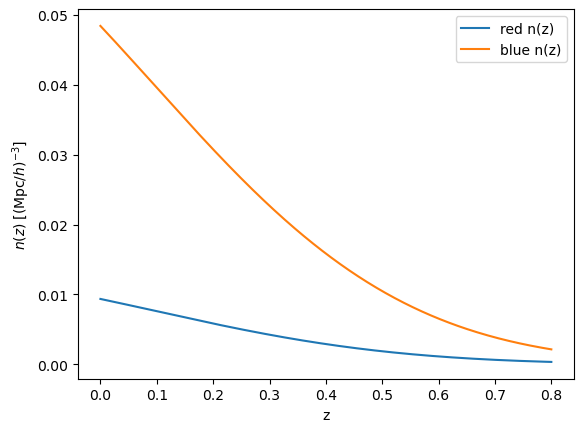

In [88]:

pred = run_from_groups_observed_space(
    groups       = groups,
    gals         = gals,       # needs 'zobs' and 'is_red' columns
    omega_matter = 0.27,
    sky_fraction = 0.0012,
    z_cutoff     = 0.8,
    pi_max       = 40.0,
)

z_plot = np.linspace(0.0, 0.8, 300)
fig, ax = plt.subplots()
ax.plot(z_plot, pred["nz_red"](z_plot),  label="red n(z)")
ax.plot(z_plot, pred["nz_blue"](z_plot), label="blue n(z)")
ax.set_xlabel("z");  ax.set_ylabel(r"$n(z)\;[(\mathrm{Mpc}/h)^{-3}]$")
ax.legend();  plt.show()
#
# 3-D correlation function
r, xi_rr, xi_bb, xi_rb = pred["r"], pred["xi_rr"], pred["xi_bb"], pred["xi_rb"]
#
# Projected correlation function
rp, wp_rr, wp_bb, wp_rb = pred["rp"], pred["wp_rr"], pred["wp_bb"], pred["wp_rb"]
plt.savefig("../plots/xi_1h_observed_space.png", dpi=300)
plt.show()
plt.clf()

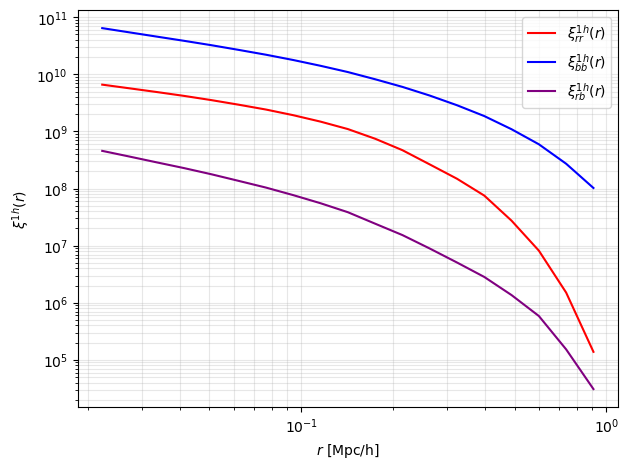

In [89]:
plt.figure()
plt.plot(rp, wp_rr, c = 'r', label=r"$\xi_{rr}^{1h}(r)$")
plt.plot(rp, wp_bb, c = 'b', label=r"$\xi_{bb}^{1h}(r)$")
plt.plot(rp, wp_rb, c='purple', label=r"$\xi_{rb}^{1h}(r)$")
plt.xscale("log")
plt.yscale("log")  # comment this out if xi_rr goes negative anywhere
plt.xlabel(r"$r$ [Mpc/h]")
plt.ylabel(r"$\xi^{1h}(r)$")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("../plots/wp_1h_observed_space.png", dpi=300)
plt.show()
plt.clf()

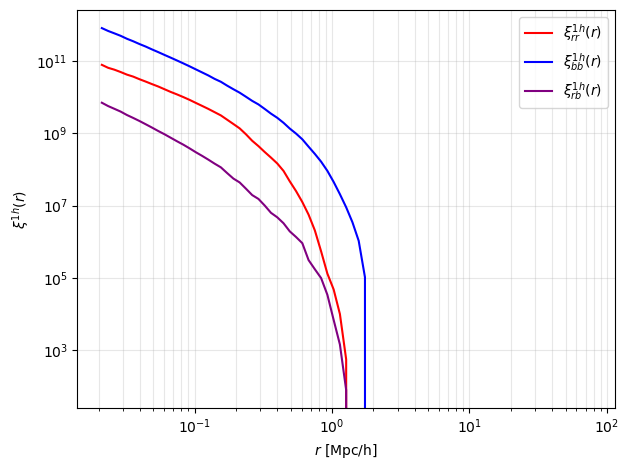

In [90]:
plt.figure()
plt.plot(r, xi_rr, c = 'r', label=r"$\xi_{rr}^{1h}(r)$")
plt.plot(r, xi_bb, c = 'b', label=r"$\xi_{bb}^{1h}(r)$")
plt.plot(r, xi_rb, c='purple', label=r"$\xi_{rb}^{1h}(r)$")
plt.xscale("log")
plt.yscale("log")  # comment this out if xi_rr goes negative anywhere
plt.xlabel(r"$r$ [Mpc/h]") 
plt.ylabel(r"$\xi^{1h}(r)$")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("../plots/xi_1h_observed_space.png", dpi=300)
plt.show()
plt.clg()

In [98]:
print(max(xi_rr), max(xi_bb), max(xi_rb))

77914154075.0901 808173106407.7886 6987035140.287923
